# Character-Level Perturbation Demo

This notebook demonstrates the `perturbation_char_level_0926` module, which applies **4 types of character-level perturbations** to text queries at varying intensity levels:

| Type | What it does |
|------|-------------|
| **Typo** | Replaces characters with nearby keyboard neighbours |
| **Deletion** | Removes characters from words |
| **Insertion** | Inserts duplicate or adjacent-key characters |
| **Transposition** | Swaps adjacent characters |

## 1. Imports

In [ ]:
import sys, os
sys.path.insert(0, "/home/ubuntu/robustness_testing")

from perturbation_char_level_2026 import (
    CharacterPerturbator,
    PerturbationType,
    TestCase,
    HybridIRModelTester,
    _expected_edits,
    hit_rate_kpi,
    adapt_model_interface,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

perturbator = CharacterPerturbator(seed=42)
print("PerturbationType members:", [p.value for p in PerturbationType])
print("Perturbator ready ✓")

PerturbationType members: ['typo', 'deletion', 'insertion', 'transposition']
Perturbator ready ✓


## 2. Sample Queries

A set of realistic IR queries of varying lengths.

In [22]:
queries = [
    "machine learning algorithms",
    "how does gradient descent work",
    "transformer architecture for natural language processing",
    "what is the difference between precision and recall",
    "deep reinforcement learning applications in robotics",
    "k-nearest neighbours classification",
    "explain batch normalisation in neural networks",
    "best practices for hyperparameter tuning with cross-validation",
    "python",
    "COVID-19 vaccine efficacy data 2024",
]

print(f"{len(queries)} sample queries:")
for i, q in enumerate(queries):
    print(f"  [{i}] ({len(q):>3d} chars, {len(q.split()):>2d} words)  {q}")

10 sample queries:
  [0] ( 27 chars,  3 words)  machine learning algorithms
  [1] ( 30 chars,  5 words)  how does gradient descent work
  [2] ( 56 chars,  6 words)  transformer architecture for natural language processing
  [3] ( 51 chars,  8 words)  what is the difference between precision and recall
  [4] ( 52 chars,  6 words)  deep reinforcement learning applications in robotics
  [5] ( 35 chars,  3 words)  k-nearest neighbours classification
  [6] ( 46 chars,  6 words)  explain batch normalisation in neural networks
  [7] ( 62 chars,  7 words)  best practices for hyperparameter tuning with cross-validation
  [8] (  6 chars,  1 words)  python
  [9] ( 35 chars,  5 words)  COVID-19 vaccine efficacy data 2024


## 3. Apply Each Perturbation Type

Run all 4 perturbation types at **low**, **moderate**, and **high** intensity on every query.

In [23]:
intensities = ["low", "moderate", "high"]

## 3b. Document Corpus & Model Interfaces

Set up a small document corpus and two lightweight model interfaces — **BM25** (sparse) and **cosine similarity over sentence embeddings** (dense). Each is wrapped in a `HybridIRModelTester` so we can use its `generate_test_cases()` and `run_test_cases()` pipeline.

In [10]:
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import re

# --- small document corpus ---
documents = [
    "Gradient descent is an optimisation algorithm used to minimise the loss function in machine learning models.",
    "Transformers use self-attention mechanisms to process sequences in parallel for natural language processing tasks.",
    "Precision measures the fraction of relevant results among retrieved items, while recall measures the fraction of relevant items retrieved.",
    "Deep reinforcement learning combines deep neural networks with reinforcement learning to solve complex control problems in robotics.",
    "K-nearest neighbours is a non-parametric classification algorithm that assigns labels based on the majority vote of nearby data points.",
    "Batch normalisation normalises layer inputs during training to accelerate convergence and improve generalisation.",
    "Hyperparameter tuning with cross-validation systematically searches for the best model settings while avoiding overfitting.",
    "COVID-19 vaccine efficacy studies compare infection rates between vaccinated and placebo groups using randomised controlled trials.",
    "Random forests are ensemble methods that aggregate many decision trees to improve predictive accuracy and control overfitting.",
    "Convolutional neural networks extract spatial features from images through learned filters applied in sliding windows.",
    "Recurrent neural networks process sequential data by maintaining a hidden state that captures information from previous time steps.",
    "Support vector machines find the optimal separating hyperplane that maximises the margin between two classes.",
    "Python is a high-level general-purpose programming language widely used in data science, web development, and automation.",
    "The bias-variance trade-off describes the tension between model complexity and generalisation error.",
    "Transfer learning reuses a pre-trained model on a new task to reduce training time and data requirements.",
]
print(f"{len(documents)} documents indexed")

# ── BM25 model interface ───────────────────────────────────────────────
def bm25_tokenize(text):
    return re.sub(r"[^\w\s]", " ", text.lower()).split()

tokenized_docs = [bm25_tokenize(doc) for doc in documents]
bm25 = BM25Okapi(tokenized_docs)

def bm25_model_interface(query, top_k=10):
    """Model interface: query → List[(doc_idx, score)]."""
    scores = bm25.get_scores(bm25_tokenize(query))
    top_idx = scores.argsort()[::-1][:top_k]
    return [(int(i), float(scores[i])) for i in top_idx]

# ── Dense model interface ──────────────────────────────────────────────
encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
doc_embeddings = encoder.encode(documents, convert_to_numpy=True)

def dense_model_interface(query, top_k=10):
    """Model interface: query → List[(doc_idx, cosine_sim)]."""
    q_vec = encoder.encode([query], convert_to_numpy=True)
    sims = cos_sim(q_vec, doc_embeddings)[0]
    top_idx = sims.argsort()[::-1][:top_k]
    return [(int(i), float(sims[i])) for i in top_idx]

# ── Create HybridIRModelTester instances ───────────────────────────────
# Option A: pass a callable (existing pattern)
bm25_tester = HybridIRModelTester(model_interface=bm25_model_interface)

# Option B: pass a model object + postprocess_fn
# The encoder itself is the model object; we define a postprocess_fn that
# converts raw cosine-similarity scores into List[Tuple[doc_id, score]].
def dense_postprocess(raw_query_embedding):
    """Convert raw encoder output to (doc_id, score) pairs."""
    sims = cos_sim(raw_query_embedding.reshape(1, -1), doc_embeddings)[0]
    top_idx = sims.argsort()[::-1][:10]
    return [(int(i), float(sims[i])) for i in top_idx]

dense_tester = HybridIRModelTester(
    model=encoder,
    query_method="encode",   # encoder.encode(query) will be called
    postprocess_fn=dense_postprocess,
)

print("BM25  tester ready ✓  (callable interface)")
print("Dense tester ready ✓  (model object + postprocess_fn)")

INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


15 documents indexed


INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cuda


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

BM25  tester ready ✓  (callable interface)
Dense tester ready ✓  (model object + postprocess_fn)


## 3c. Generate & Score Test Cases via `HybridIRModelTester`

**New features demonstrated here:**

1. **`random_type=True`** — each query gets one randomly chosen perturbation type instead of iterating over all four.
2. **`kpi_fn` + `ground_truth`** — a user-defined KPI function (`hit_rate_kpi`) is passed at run-time together with relevance labels to evaluate document-level hit-rate before and after perturbation.

| Metric | What it measures |
|--------|-----------------|
| **Kendall τ** | Rank correlation between original and perturbed result lists |
| **Top-1 score Δ** | Change in the highest-scoring document's score |
| **Top-5 Jaccard** | Overlap of the top-5 document sets |
| **hit_rate@k** | Fraction of queries with ≥ 1 relevant doc in top-k (KPI) |

In [11]:
intensities

['low', 'moderate', 'high']

In [24]:
# ── Ground-truth relevance labels ──────────────────────────────────────
# Maps each query to the set of doc indices considered relevant.
ground_truth = {
    "machine learning algorithms":                                    {0, 8},
    "how does gradient descent work":                                 {0},
    "transformer architecture for natural language processing":       {1},
    "what is the difference between precision and recall":            {2},
    "deep reinforcement learning applications in robotics":           {3},
    "k-nearest neighbours classification":                            {4},
    "explain batch normalisation in neural networks":                 {5},
    "best practices for hyperparameter tuning with cross-validation": {6},
    "python":                                                         {12},
    "COVID-19 vaccine efficacy data 2024":                            {7},
}

# ── Generate test cases (random_type=True: one random perturbation per query) ─
bm25_cases  = bm25_tester.generate_test_cases(queries, intensity_levels=intensities, random_type=True)
dense_cases = dense_tester.generate_test_cases(queries, intensity_levels=intensities, random_type=True)

print(f"Generated {len(bm25_cases)} test cases per scorer  (random_type=True → 1 type per query)")
print(f"  Example: '{bm25_cases[0].original_query}' → '{bm25_cases[0].perturbed_query}'  "
      f"[{bm25_cases[0].perturbation_type.value}, {bm25_cases[0].intensity}]")

# ── Run scoring + built-in KPI (hit_rate) ─────────────────────────────
bm25_results  = bm25_tester.run_test_cases(
    bm25_cases,
    kpi_fn=hit_rate_kpi,
    ground_truth=ground_truth,
    kpi_kwargs={"k": 5},
)
dense_results = dense_tester.run_test_cases(
    dense_cases,
    kpi_fn=hit_rate_kpi,
    ground_truth=ground_truth,
    kpi_kwargs={"k": 5},
)

# # Tag each result with its scorer and merge
# bm25_results["scorer"]  = "BM25"
# dense_results["scorer"] = "Dense"
# score_df = pd.concat([bm25_results, dense_results], ignore_index=True)

# print(f"\nScored {len(score_df)} (query × perturbation × scorer) combinations")
# print("\n── KPI Summary ──")
# print(f"  BM25  → {bm25_tester.test_results['kpi']}")
# print(f"  Dense → {dense_tester.test_results['kpi']}")
# score_df.head(12)

INFO:perturbation_char_level_2026:KPI [low] original:  {'hit_rate@5': 1.0}
INFO:perturbation_char_level_2026:KPI [low] perturbed: {'hit_rate@5': 0.1}
INFO:perturbation_char_level_2026:KPI [moderate] original:  {'hit_rate@5': 1.0}
INFO:perturbation_char_level_2026:KPI [moderate] perturbed: {'hit_rate@5': 0.1}
INFO:perturbation_char_level_2026:KPI [high] original:  {'hit_rate@5': 1.0}
INFO:perturbation_char_level_2026:KPI [high] perturbed: {'hit_rate@5': 0.1}
INFO:perturbation_char_level_2026:
              CER  top1_score_orig  top1_score_pert  top1_delta  top5_jaccard     rbo  hit_rate@5_orig  hit_rate@5_pert  hit_rate@5_delta
intensity                                                                                                                                
low        0.2354           7.1937           4.9837     -2.2101        0.8429  0.9008              1.0              0.1              -0.9
moderate   0.2276           7.1937           4.4545     -2.7392        0.8095  0.9187    

Generated 30 test cases per scorer  (random_type=True → 1 type per query)
  Example: 'machine learning algorithms' → 'machone learnimg algorithms'  [typo, low]


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:perturbation_char_level_2026:KPI [low] original:  {'hit_rate@5': 1.0}
INFO:perturbation_char_level_2026:KPI [low] perturbed: {'hit_rate@5': 0.1}
INFO:perturbation_char_level_2026:KPI [moderate] original:  {'hit_rate@5': 1.0}
INFO:perturbation_char_level_2026:KPI [moderate] perturbed: {'hit_rate@5': 0.1}
INFO:perturbation_char_level_2026:KPI [high] original:  {'hit_rate@5': 1.0}
INFO:perturbation_char_level_2026:KPI [high] perturbed: {'hit_rate@5': 0.1}
INFO:perturbation_char_level_2026:
              CER  top1_score_orig  top1_score_pert  top1_delta  top5_jaccard     rbo  hit_rate@5_orig  hit_rate@5_pert  hit_rate@5_delta
intensity                                                                                                                                
low        0.2335           0.7448           0.5496     -0.1951        0.6619  0.8336              1.0              0.1              -0.9
moderate   0.2131           0.7448           0.5900     -0.1547        0.5826  0.8130    

## 3e. Scorer Robustness Summary

Mean robustness metrics aggregated by **scorer × perturbation type × intensity**.

In [14]:
robustness_summary = (
    score_df
    .groupby(["scorer", "type", "intensity"])
    .agg(
        mean_tau=("kendall_tau", "mean"),
        mean_jaccard=("top5_jaccard", "mean"),
        mean_top1_delta=("top1_delta", "mean"),
        mean_CER=("CER", "mean"),
    )
    .round(4)
    .reset_index()
)

robustness_summary["intensity"] = pd.Categorical(
    robustness_summary["intensity"], categories=intensities, ordered=True
)
robustness_summary = robustness_summary.sort_values(
    ["scorer", "type", "intensity"]
).reset_index(drop=True)

display(robustness_summary)

KeyError: 'type'

## 3f. Custom KPI Example

You can supply **any** KPI function.  Below we define a custom *mean-reciprocal-rank (MRR)* KPI and pass it to `run_test_cases()` while also demonstrating `set_kpi_fn()`.

In [25]:
# ── Custom KPI: Mean Reciprocal Rank ──────────────────────────────────
def mrr_kpi(queries, retrieved_docs, ground_truth, **kwargs):
    """Mean Reciprocal Rank across all queries."""
    rr_sum = 0.0
    for q, docs in zip(queries, retrieved_docs):
        relevant = ground_truth.get(q, set())
        for rank, (doc_id, _) in enumerate(docs, start=1):
            if doc_id in relevant:
                rr_sum += 1.0 / rank
                break
    return {"MRR": round(rr_sum / max(len(queries), 1), 4)}

# Set it on the tester so every subsequent run uses it automatically
bm25_tester.set_kpi_fn(mrr_kpi)

# Re-run with the new KPI (reuse existing test cases)
bm25_results_mrr = bm25_tester.run_test_cases(
    bm25_cases, ground_truth=ground_truth,
)
print("BM25 KPI (MRR):", bm25_tester.test_results["kpi"])

INFO:perturbation_char_level_2026:KPI [low] original:  {'MRR': 1.0}
INFO:perturbation_char_level_2026:KPI [low] perturbed: {'MRR': 0.1}
INFO:perturbation_char_level_2026:KPI [moderate] original:  {'MRR': 1.0}
INFO:perturbation_char_level_2026:KPI [moderate] perturbed: {'MRR': 0.1}
INFO:perturbation_char_level_2026:KPI [high] original:  {'MRR': 1.0}
INFO:perturbation_char_level_2026:KPI [high] perturbed: {'MRR': 0.1}
INFO:perturbation_char_level_2026:
              CER  top1_score_orig  top1_score_pert  top1_delta  top5_jaccard     rbo  MRR_orig  MRR_pert  MRR_delta
intensity                                                                                                           
low        0.2354           7.1937           4.9837     -2.2101        0.8429  0.9008       1.0       0.1       -0.9
moderate   0.2276           7.1937           4.4545     -2.7392        0.8095  0.9187       1.0       0.1       -0.9
high       0.3207           7.1937           4.2252     -2.9686        0.7774

BM25 KPI (MRR): {'low': {'original': {'MRR': 1.0}, 'perturbed': {'MRR': 0.1}}, 'moderate': {'original': {'MRR': 1.0}, 'perturbed': {'MRR': 0.1}}, 'high': {'original': {'MRR': 1.0}, 'perturbed': {'MRR': 0.1}}}


## 3g. Demo: Different Model Objects, Custom Postprocessing & Custom KPI

This section demonstrates three key patterns:

1. **Different model objects** — plug in any model via the `model=` + `query_method=` interface
2. **Custom postprocessing** — normalise / standardise raw model outputs into the expected `List[Tuple[doc_id, score]]` format
3. **Custom KPI function** — evaluate retrieval quality with your own metric (NDCG@k shown here)

In [26]:
from perturbation_char_level_2026 import (
    HybridIRModelTester, PerturbationType, adapt_model_interface, hit_rate_kpi, _rbo,
)
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# ═══════════════════════════════════════════════════════════════════════
# 1) DIFFERENT MODEL OBJECTS
#    Any object with a callable method can be plugged in via
#    model= + query_method=.  No wrapper function needed.
# ═══════════════════════════════════════════════════════════════════════

# ── Model A: BM25 (already instantiated above) ────────────────────────
# BM25Okapi has `get_scores(tokenized_query)` → numpy array of scores
# We'll wrap it in a tiny class to show the pattern cleanly.

class BM25Wrapper:
    """Thin wrapper so we can pass `model=bm25_w, query_method='search'`."""
    def __init__(self, bm25_index):
        self.bm25 = bm25_index

    def search(self, query: str):
        """Raw output: 1-D numpy array of BM25 scores (one per doc)."""
        tokens = re.sub(r"[^\w\s]", " ", query.lower()).split()
        return self.bm25.get_scores(tokens)           # shape (n_docs,)

bm25_w = BM25Wrapper(bm25)

# ── Model B: Dense SentenceTransformer (reuse `encoder` from above) ───
# encoder.encode(query) → 1-D numpy array (embedding), not scores.
# We need a postprocess_fn to turn that into (doc_id, score) pairs.

# ── Model C: A simple TF-IDF scorer (dict-based, no library needed) ───
from collections import Counter
import math as _math

class TFIDFScorer:
    """Minimal TF-IDF scorer for demonstration."""
    def __init__(self, docs):
        self.docs = docs
        self.n = len(docs)
        self.tokenized = [self._tok(d) for d in docs]
        self.idf = self._compute_idf()

    @staticmethod
    def _tok(text):
        return re.sub(r"[^\w\s]", " ", text.lower()).split()

    def _compute_idf(self):
        df = Counter()
        for toks in self.tokenized:
            for t in set(toks):
                df[t] += 1
        return {t: _math.log((self.n + 1) / (c + 1)) + 1 for t, c in df.items()}

    def score(self, query: str):
        """Raw output: dict {doc_index: tfidf_score}."""
        qtoks = self._tok(query)
        results = {}
        for i, dtoks in enumerate(self.tokenized):
            tf = Counter(dtoks)
            s = sum(tf.get(qt, 0) * self.idf.get(qt, 0) for qt in qtoks)
            if s > 0:
                results[i] = s
        return results                                  # dict[int, float]

tfidf = TFIDFScorer(documents)

print("Three model objects ready:")
print(f"  A) BM25Wrapper  — search() → np.ndarray")
print(f"  B) SentenceTransformer — encode() → np.ndarray (embedding)")
print(f"  C) TFIDFScorer  — score() → dict[int, float]")

Three model objects ready:
  A) BM25Wrapper  — search() → np.ndarray
  B) SentenceTransformer — encode() → np.ndarray (embedding)
  C) TFIDFScorer  — score() → dict[int, float]


In [27]:
# ═══════════════════════════════════════════════════════════════════════
# 2) CUSTOM POSTPROCESSING
#    Each model returns a different shape.  postprocess_fn standardises
#    everything into List[Tuple[doc_id, score]].
# ═══════════════════════════════════════════════════════════════════════

# --- Postprocessor for Model A (BM25): ndarray → top-k (id, score) ---
def bm25_postprocess(scores_array, top_k=10):
    """np.ndarray of per-doc scores → List[Tuple[doc_id, score]]."""
    top_idx = scores_array.argsort()[::-1][:top_k]
    return [(int(i), float(scores_array[i])) for i in top_idx]

# --- Postprocessor for Model B (Dense): embedding → cosine sim → top-k ---
def dense_postprocess(embedding, top_k=10):
    """1-D embedding → cosine similarity → List[Tuple[doc_id, score]]."""
    sims = cos_sim(embedding.reshape(1, -1), doc_embeddings)[0]
    top_idx = sims.argsort()[::-1][:top_k]
    return [(int(i), float(sims[i])) for i in top_idx]

# --- Postprocessor for Model C (TF-IDF): dict → sorted top-k pairs ---
def tfidf_postprocess(score_dict, top_k=10):
    """dict[doc_id, score] → sorted List[Tuple[doc_id, score]]."""
    pairs = sorted(score_dict.items(), key=lambda x: x[1], reverse=True)
    return [(int(k), float(v)) for k, v in pairs[:top_k]]

# ═══════════════════════════════════════════════════════════════════════
# Build testers — each with model= + query_method= + postprocess_fn=
# ═══════════════════════════════════════════════════════════════════════

tester_a = HybridIRModelTester(
    model=bm25_w,
    query_method="search",           # calls bm25_w.search(query)
    postprocess_fn=bm25_postprocess,
)

tester_b = HybridIRModelTester(
    model=encoder,
    query_method="encode",           # calls encoder.encode(query)
    postprocess_fn=dense_postprocess,
)

tester_c = HybridIRModelTester(
    model=tfidf,
    query_method="score",            # calls tfidf.score(query)
    postprocess_fn=tfidf_postprocess,
)

# Quick sanity check — each tester should return standardised output
for label, tester in [("BM25", tester_a), ("Dense", tester_b), ("TF-IDF", tester_c)]:
    result = tester.score_query("machine learning algorithms")
    print(f"{label:8s} top-3: {result[:3]}")

print("\n✓ All three testers return List[Tuple[doc_id, score]]")

BM25     top-3: [(0, 3.593817536205199), (3, 1.8021720428234402), (14, 1.2241003784474453)]


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Dense    top-3: [(0, 0.5161649584770203), (11, 0.44394636154174805), (4, 0.4167843163013458)]
TF-IDF   top-3: [(0, 5.465735902799727), (3, 4.772588722239782), (14, 2.386294361119891)]

✓ All three testers return List[Tuple[doc_id, score]]


In [28]:
# ═══════════════════════════════════════════════════════════════════════
# 3) CUSTOM KPI FUNCTION
#    Define NDCG@k as a custom KPI, then run the full pipeline.
# ═══════════════════════════════════════════════════════════════════════

def ndcg_kpi(queries, retrieved_docs, ground_truth, k=5):
    """Normalised Discounted Cumulative Gain @ k.

    Parameters — same signature as hit_rate_kpi:
        queries:        List[str]
        retrieved_docs: List[List[Tuple[doc_id, score]]]
        ground_truth:   Dict[str, set]   (query → set of relevant doc_ids)
        k:              int
    Returns:
        {"NDCG@k": float}
    """
    ndcg_scores = []
    for q, docs in zip(queries, retrieved_docs):
        relevant = ground_truth.get(q, set())
        # DCG: relevance is binary (1 if doc is relevant, 0 otherwise)
        dcg = sum(
            (1.0 / _math.log2(rank + 1)) if doc_id in relevant else 0.0
            for rank, (doc_id, _) in enumerate(docs[:k], start=1)
        )
        # Ideal DCG: all relevant docs ranked first
        n_rel = min(len(relevant), k)
        idcg = sum(1.0 / _math.log2(r + 1) for r in range(1, n_rel + 1))
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)

    return {f"NDCG@{k}": round(sum(ndcg_scores) / max(len(ndcg_scores), 1), 4)}

# ── Generate test cases & run with NDCG KPI on all three models ───────
test_queries = queries[:6]   # use a subset for speed

results_all = {}
for label, tester in [("BM25", tester_a), ("Dense", tester_b), ("TF-IDF", tester_c)]:
    cases = tester.generate_test_cases(
        test_queries,
        perturbation_types=[PerturbationType.TYPO, PerturbationType.TRANSPOSITION],
        random_type=True,
    )
    summary = tester.run_test_cases(
        cases,
        kpi_fn=ndcg_kpi,
        ground_truth=ground_truth,
        kpi_kwargs={"k": 5},
        ranking_metric="rbo",   # use RBO (works for top-k models like BM25)
        rbo_p=0.9,
    )
    results_all[label] = summary
    print(f"\n{'═'*60}")
    print(f"  {label} — Summary by intensity")
    print(f"{'═'*60}")
    print(summary.to_string())
    print(f"\n  KPI breakdown: {tester.test_results['kpi']}")

INFO:perturbation_char_level_2026:KPI [low] original:  {'NDCG@5': 0.9355}
INFO:perturbation_char_level_2026:KPI [low] perturbed: {'NDCG@5': 0.0}
INFO:perturbation_char_level_2026:KPI [moderate] original:  {'NDCG@5': 0.9355}
INFO:perturbation_char_level_2026:KPI [moderate] perturbed: {'NDCG@5': 0.0}
INFO:perturbation_char_level_2026:KPI [high] original:  {'NDCG@5': 0.9355}
INFO:perturbation_char_level_2026:KPI [high] perturbed: {'NDCG@5': 0.0}
INFO:perturbation_char_level_2026:
              CER  top1_score_orig  top1_score_pert  top1_delta  top5_jaccard     rbo  NDCG@5_orig  NDCG@5_pert  NDCG@5_delta
intensity                                                                                                                    
low        0.0692           6.7363           4.0473     -2.6890        0.8492  0.9032       0.9355          0.0       -0.9355
moderate   0.0946           6.7363           3.4109     -3.3254        0.8492  0.9408       0.9355          0.0       -0.9355
high       0.1


════════════════════════════════════════════════════════════
  BM25 — Summary by intensity
════════════════════════════════════════════════════════════
              CER  top1_score_orig  top1_score_pert  top1_delta  top5_jaccard     rbo  NDCG@5_orig  NDCG@5_pert  NDCG@5_delta
intensity                                                                                                                    
low        0.0692           6.7363           4.0473     -2.6890        0.8492  0.9032       0.9355          0.0       -0.9355
moderate   0.0946           6.7363           3.4109     -3.3254        0.8492  0.9408       0.9355          0.0       -0.9355
high       0.1065           6.7363           3.3791     -3.3571        0.8889  0.9364       0.9355          0.0       -0.9355

  KPI breakdown: {'low': {'original': {'NDCG@5': 0.9355}, 'perturbed': {'NDCG@5': 0.0}}, 'moderate': {'original': {'NDCG@5': 0.9355}, 'perturbed': {'NDCG@5': 0.0}}, 'high': {'original': {'NDCG@5': 0.9355}, 'perturbed

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:perturbation_char_level_2026:KPI [low] original:  {'NDCG@5': 0.9795}
INFO:perturbation_char_level_2026:KPI [low] perturbed: {'NDCG@5': 0.0}
INFO:perturbation_char_level_2026:KPI [moderate] original:  {'NDCG@5': 0.9795}
INFO:perturbation_char_level_2026:KPI [moderate] perturbed: {'NDCG@5': 0.0}
INFO:perturbation_char_level_2026:KPI [high] original:  {'NDCG@5': 0.9795}
INFO:perturbation_char_level_2026:KPI [high] perturbed: {'NDCG@5': 0.0}
INFO:perturbation_char_level_2026:
              CER  top1_score_orig  top1_score_pert  top1_delta  top5_jaccard     rbo  NDCG@5_orig  NDCG@5_pert  NDCG@5_delta
intensity                                                                                                                    
low        0.0595            0.728           0.6080     -0.1200        0.7222  0.7788       0.9795          0.0       -0.9795
moderate   0.1007            0.728           0.5185     -0.2094        0.5278  0.7834       0.9795          0.0       -0.9795
high       0.1


════════════════════════════════════════════════════════════
  Dense — Summary by intensity
════════════════════════════════════════════════════════════
              CER  top1_score_orig  top1_score_pert  top1_delta  top5_jaccard     rbo  NDCG@5_orig  NDCG@5_pert  NDCG@5_delta
intensity                                                                                                                    
low        0.0595            0.728           0.6080     -0.1200        0.7222  0.7788       0.9795          0.0       -0.9795
moderate   0.1007            0.728           0.5185     -0.2094        0.5278  0.7834       0.9795          0.0       -0.9795
high       0.1195            0.728           0.4732     -0.2548        0.4782  0.7643       0.9795          0.0       -0.9795

  KPI breakdown: {'low': {'original': {'NDCG@5': 0.9795}, 'perturbed': {'NDCG@5': 0.0}}, 'moderate': {'original': {'NDCG@5': 0.9795}, 'perturbed': {'NDCG@5': 0.0}}, 'high': {'original': {'NDCG@5': 0.9795}, 'perturbe

intensity    CER  top1_score_orig  top1_score_pert  top1_delta  top5_jaccard    rbo  NDCG@5_orig  NDCG@5_pert  NDCG@5_delta  model
      low 0.0692           6.7363           4.0473     -2.6890        0.8492 0.9032       0.9355          0.0       -0.9355   BM25
 moderate 0.0946           6.7363           3.4109     -3.3254        0.8492 0.9408       0.9355          0.0       -0.9355   BM25
     high 0.1065           6.7363           3.3791     -3.3571        0.8889 0.9364       0.9355          0.0       -0.9355   BM25
      low 0.0595           0.7280           0.6080     -0.1200        0.7222 0.7788       0.9795          0.0       -0.9795  Dense
 moderate 0.1007           0.7280           0.5185     -0.2094        0.5278 0.7834       0.9795          0.0       -0.9795  Dense
     high 0.1195           0.7280           0.4732     -0.2548        0.4782 0.7643       0.9795          0.0       -0.9795  Dense
      low 0.0692          11.2353           8.3390     -2.8963        0.8889 0.8825

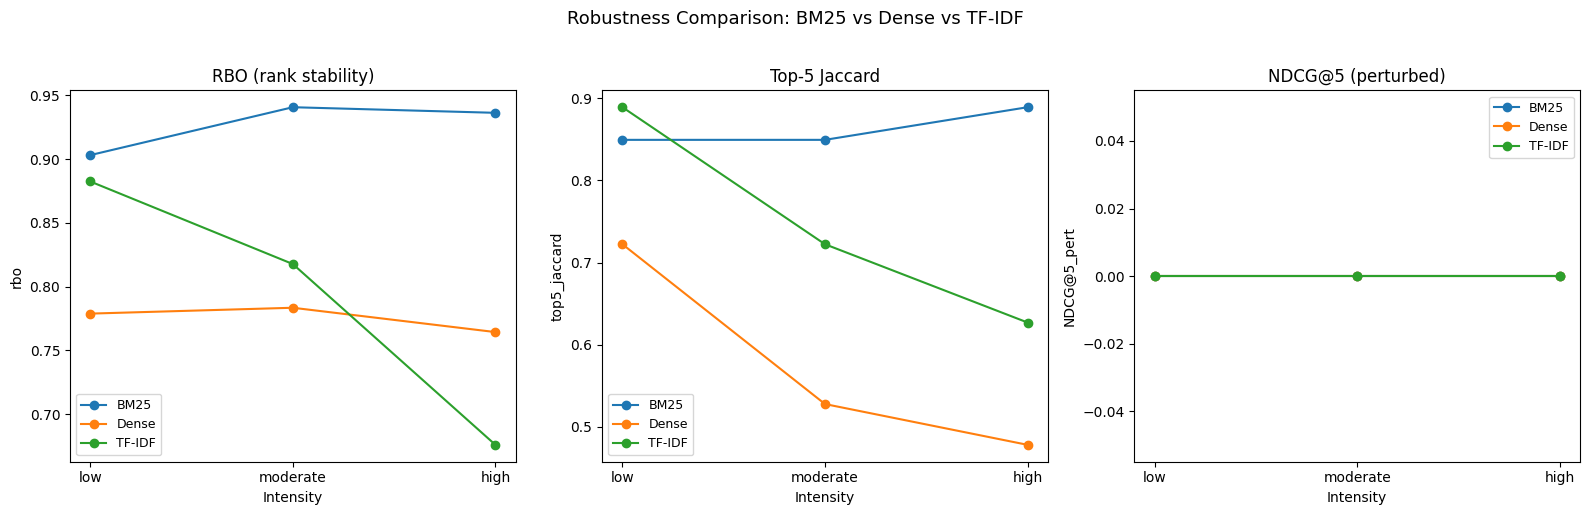

In [29]:
# ═══════════════════════════════════════════════════════════════════════
# 4) COMPARE ALL THREE MODELS SIDE-BY-SIDE
# ═══════════════════════════════════════════════════════════════════════

comparison = pd.concat(
    [df.assign(model=name) for name, df in results_all.items()],
    ignore_index=False,
)
comparison.index.name = "intensity"
print(comparison.reset_index().to_string(index=False))

# ── Visual comparison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, metric, title in zip(
    axes,
    ["rbo", "top5_jaccard", "NDCG@5_pert"],
    ["RBO (rank stability)", "Top-5 Jaccard", "NDCG@5 (perturbed)"],
):
    if metric not in comparison.columns:
        ax.set_visible(False)
        continue
    for model_name in results_all:
        sub = comparison[comparison["model"] == model_name]
        ax.plot(sub.index, sub[metric], marker="o", label=model_name)
    ax.set_xlabel("Intensity")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle("Robustness Comparison: BM25 vs Dense vs TF-IDF", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Side-by-Side Examples

Show original vs perturbed text for one query across all types/intensities.

In [10]:
example_query = "transformer architecture for natural language processing"
print(f"Original:  {example_query}\n{'─'*70}")

for pt in ptypes:
    print(f"\n  {pt.value.upper()}")
    for intensity in intensities:
        p = perturbator.apply_perturbation(example_query, pt, intensity)
        # Highlight changed characters
        diff_markers = "".join("^" if i < len(p) and (i >= len(example_query) or example_query[i] != p[i]) else " "
                               for i in range(max(len(example_query), len(p))))
        print(f"    {intensity:<10s}  {p}")
        if diff_markers.strip():
            print(f"    {'':10s}  {diff_markers}")

Original:  transformer architecture for natural language processing
──────────────────────────────────────────────────────────────────────

  TYPO
    low         transfo4mer architecture for natural language proceszing
                       ^                                            ^   
    moderate    transformer architecture fpr natural langusge procesaing
                                          ^               ^         ^   
    high        transformer architecture fir naturap lantuage processing
                                          ^        ^    ^               

  DELETION
    low         transformer architecture fr natural language proessing
                                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^  
    moderate    transfomer architecture fr natural language processing
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^ ^^^^^^^^^^^^^^^^^^  
    high        transformer architeture for naural language processng
                                   ^^^^^^^^^^

## 6. CER vs Query Length

How does perturbation intensity scale with the length of the input query?

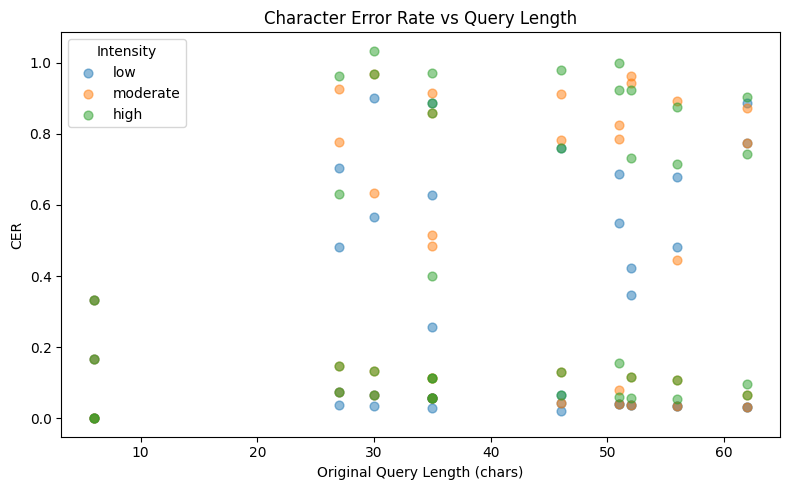

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for intensity in intensities:
    subset = df[df["intensity"] == intensity]
    ax.scatter(subset["orig_len"], subset["CER"], alpha=0.5, label=intensity, s=40)

ax.set_xlabel("Original Query Length (chars)")
ax.set_ylabel("CER")
ax.set_title("Character Error Rate vs Query Length")
ax.legend(title="Intensity")
plt.tight_layout()
plt.show()

In [ ]:
## 7. REST API with Nested Response + Chunk & Document Hit-Rate KPIs

This section demonstrates:

1. **Simulated REST API** returning a nested response dict: `{"results": [{"chunk_id": ..., "_score": ..., "section": ..., "document": ...}]}`
2. **`adapt_model_interface`** to convert the nested response into `List[Tuple[chunk_id, score]]`
3. **Chunk-level hit rate@3** — is the ground-truth *chunk* (matched by section name) in the top 3?
4. **Document-level hit rate@3** — is *any* chunk from the ground-truth document in the top 3?

In [30]:
from perturbation_char_level_2026 import adapt_model_interface, HybridIRModelTester, PerturbationType
from rank_bm25 import BM25Okapi
import re

# ═══════════════════════════════════════════════════════════════════════
# 1) CHUNK CORPUS — each chunk belongs to a section and a document
# ═══════════════════════════════════════════════════════════════════════
CHUNKS = [
    # ── Document: "ML Fundamentals" ────────────────────────────────────
    {"chunk_id": 0, "section": "Optimisation",      "document": "ML Fundamentals",
     "text": "Gradient descent is an optimisation algorithm used to minimise the loss function in machine learning models."},
    {"chunk_id": 1, "section": "Optimisation",      "document": "ML Fundamentals",
     "text": "Stochastic gradient descent samples mini-batches to estimate the gradient, trading variance for speed."},
    {"chunk_id": 2, "section": "Ensemble Methods",  "document": "ML Fundamentals",
     "text": "Random forests aggregate many decision trees to improve predictive accuracy and control overfitting."},
    {"chunk_id": 3, "section": "Ensemble Methods",  "document": "ML Fundamentals",
     "text": "Boosting builds trees sequentially, each correcting errors made by the previous model."},

    # ── Document: "Deep Learning" ──────────────────────────────────────
    {"chunk_id": 4, "section": "Transformers",       "document": "Deep Learning",
     "text": "Transformers use self-attention mechanisms to process sequences in parallel for NLP tasks."},
    {"chunk_id": 5, "section": "Transformers",       "document": "Deep Learning",
     "text": "Multi-head attention projects queries, keys, and values into multiple subspaces for richer representations."},
    {"chunk_id": 6, "section": "CNNs",               "document": "Deep Learning",
     "text": "Convolutional neural networks extract spatial features from images through learned filters in sliding windows."},
    {"chunk_id": 7, "section": "Batch Normalisation","document": "Deep Learning",
     "text": "Batch normalisation normalises layer inputs during training to accelerate convergence."},

    # ── Document: "Evaluation Metrics" ─────────────────────────────────
    {"chunk_id": 8,  "section": "Classification",    "document": "Evaluation Metrics",
     "text": "Precision measures the fraction of relevant results among retrieved items; recall measures the fraction of relevant items retrieved."},
    {"chunk_id": 9,  "section": "Classification",    "document": "Evaluation Metrics",
     "text": "The F1 score is the harmonic mean of precision and recall, balancing both metrics in a single number."},
    {"chunk_id": 10, "section": "Ranking",           "document": "Evaluation Metrics",
     "text": "Mean reciprocal rank evaluates how early the first relevant result appears in a ranked list."},

    # ── Document: "Programming" ────────────────────────────────────────
    {"chunk_id": 11, "section": "Python",            "document": "Programming",
     "text": "Python is a high-level general-purpose programming language widely used in data science and automation."},
    {"chunk_id": 12, "section": "Python",            "document": "Programming",
     "text": "List comprehensions in Python provide a concise way to create lists from existing iterables."},
]

# Lookup tables: chunk_id → section / document
CHUNK_SECTION  = {c["chunk_id"]: c["section"]  for c in CHUNKS}
CHUNK_DOCUMENT = {c["chunk_id"]: c["document"] for c in CHUNKS}

print(f"{len(CHUNKS)} chunks across {len(set(CHUNK_DOCUMENT.values()))} documents, "
      f"{len(set(CHUNK_SECTION.values()))} sections")
for c in CHUNKS:
    print(f"  [{c['chunk_id']:2d}] {c['document']:20s} | {c['section']:20s} | {c['text'][:60]}…")

13 chunks across 4 documents, 8 sections
  [ 0] ML Fundamentals      | Optimisation         | Gradient descent is an optimisation algorithm used to minimi…
  [ 1] ML Fundamentals      | Optimisation         | Stochastic gradient descent samples mini-batches to estimate…
  [ 2] ML Fundamentals      | Ensemble Methods     | Random forests aggregate many decision trees to improve pred…
  [ 3] ML Fundamentals      | Ensemble Methods     | Boosting builds trees sequentially, each correcting errors m…
  [ 4] Deep Learning        | Transformers         | Transformers use self-attention mechanisms to process sequen…
  [ 5] Deep Learning        | Transformers         | Multi-head attention projects queries, keys, and values into…
  [ 6] Deep Learning        | CNNs                 | Convolutional neural networks extract spatial features from …
  [ 7] Deep Learning        | Batch Normalisation  | Batch normalisation normalises layer inputs during training …
  [ 8] Evaluation Metrics   | Classific

In [32]:
# ═══════════════════════════════════════════════════════════════════════
# 2) SIMULATED REST API — returns a nested response dict
#    Mimics what you'd get from an Elasticsearch / custom search service.
# ═══════════════════════════════════════════════════════════════════════

# Build a BM25 index over the chunk texts
_tok = lambda t: re.sub(r"[^\w\s]", " ", t.lower()).split()
_bm25_chunks = BM25Okapi([_tok(c["text"]) for c in CHUNKS])

def fake_search_api(query, top_k=5):
    """Simulated REST API.

    Returns a nested dict like a real search service would::

        {
            "status": "ok",
            "total":  <int>,
            "results": [
                {"chunk_id": 0, "_score": 3.21,
                 "section": "Optimisation", "document": "ML Fundamentals",
                 "text": "Gradient descent is …"},
                ...
            ]
        }
    """
    scores = _bm25_chunks.get_scores(_tok(query))
    top_idx = scores.argsort()[::-1][:top_k]
    hits = []
    for i in top_idx:
        c = CHUNKS[i]
        hits.append({
            "chunk_id": c["chunk_id"],
            "_score":   round(float(scores[i]), 4),
            "section":  c["section"],
            "document": c["document"],
            "text":     c["text"],
        })
    return {
        "status":  "ok",
        "total":   len(hits),
        "results": hits,
    }

# ── Quick test: see the raw nested response ────────────────────────────
raw = fake_search_api("gradient descent optimisation")
print("Raw API response keys:", list(raw.keys()))
print(f"  status: {raw['status']},  total: {raw['total']}")
for h in raw["results"][:3]:
    print(f"  chunk_id={h['chunk_id']}  score={h['_score']:.3f}  "
          f"section={h['section']!r}  doc={h['document']!r}")

Raw API response keys: ['status', 'total', 'results']
  status: ok,  total: 5
  chunk_id=0  score=4.924  section='Optimisation'  doc='ML Fundamentals'
  chunk_id=1  score=3.744  section='Optimisation'  doc='ML Fundamentals'
  chunk_id=10  score=0.000  section='Ranking'  doc='Evaluation Metrics'


In [4]:
# ═══════════════════════════════════════════════════════════════════════
# 3) ADAPT THE API → HybridIRModelTester
#    Use adapt_model_interface to drill into the nested "results" key
#    and extract (chunk_id, _score) pairs.
# ═══════════════════════════════════════════════════════════════════════

adapted_api = adapt_model_interface(
    fake_search_api,
    response_key="results",    # unwrap {"results": [...]}
    id_field="chunk_id",       # use "chunk_id" as the doc id
    score_field="_score",      # use "_score" as the score
    top_k=5,
    extra_kwargs={"top_k": 5},
)

# Verify: should return List[Tuple[int, float]]
demo_result = adapted_api("gradient descent optimisation")
print("Adapted output (List[Tuple[chunk_id, score]]):")
for chunk_id, score in demo_result:
    section = CHUNK_SECTION[chunk_id]
    document = CHUNK_DOCUMENT[chunk_id]
    print(f"  chunk_id={chunk_id}  score={score:.3f}  section={section!r}  doc={document!r}")

# ── Create the tester ──────────────────────────────────────────────────
api_tester = HybridIRModelTester(model_interface=adapted_api)
print("\n✓ API tester ready (adapt_model_interface + nested response)")

NameError: name 'adapt_model_interface' is not defined

In [2]:
# ═══════════════════════════════════════════════════════════════════════
# 4) GROUND TRUTH & CUSTOM KPIs
#
#    ground_truth maps query → set of relevant *chunk_ids* (ints)
#    which is the format HybridIRModelTester expects.
#
#    The KPI functions use the CHUNK_SECTION / CHUNK_DOCUMENT
#    lookup tables to evaluate at two levels:
#      - Chunk-level:    exact section match in top-k
#      - Document-level: any chunk from the correct document in top-k
# ═══════════════════════════════════════════════════════════════════════

# ── Queries and ground truth ───────────────────────────────────────────
api_queries = [
    "gradient descent optimisation",
    "transformer self-attention NLP",
    "precision recall classification",
    "random forest ensemble",
    "batch normalisation training",
    "python programming language",
]

# Ground truth: query → set of relevant chunk_ids
api_ground_truth = {
    "gradient descent optimisation":      {0, 1},    # section: Optimisation
    "transformer self-attention NLP":     {4, 5},    # section: Transformers
    "precision recall classification":    {8, 9},    # section: Classification
    "random forest ensemble":             {2, 3},    # section: Ensemble Methods
    "batch normalisation training":       {7},       # section: Batch Normalisation
    "python programming language":        {11, 12},  # section: Python
}

# Also define expected section names and document names for the KPIs
QUERY_RELEVANT_SECTIONS = {
    "gradient descent optimisation":      {"Optimisation"},
    "transformer self-attention NLP":     {"Transformers"},
    "precision recall classification":    {"Classification"},
    "random forest ensemble":             {"Ensemble Methods"},
    "batch normalisation training":       {"Batch Normalisation"},
    "python programming language":        {"Python"},
}

QUERY_RELEVANT_DOCUMENTS = {
    "gradient descent optimisation":      {"ML Fundamentals"},
    "transformer self-attention NLP":     {"Deep Learning"},
    "precision recall classification":    {"Evaluation Metrics"},
    "random forest ensemble":             {"ML Fundamentals"},
    "batch normalisation training":       {"Deep Learning"},
    "python programming language":        {"Programming"},
}


# ── Chunk-level hit rate@k ─────────────────────────────────────────────
def chunk_hit_rate_kpi(queries, retrieved_docs, ground_truth, k=3,
                       chunk_section=None, relevant_sections=None, **kwargs):
    """Chunk-level hit rate: is any chunk from the ground-truth *section*
    in the top-k results?

    Checks by matching the section name of each retrieved chunk against the
    set of relevant section names for the query.
    """
    chunk_section = chunk_section or CHUNK_SECTION
    relevant_sections = relevant_sections or QUERY_RELEVANT_SECTIONS

    hits = 0
    for q, docs in zip(queries, retrieved_docs):
        expected_sections = relevant_sections.get(q, set())
        retrieved_sections = {
            chunk_section.get(chunk_id) for chunk_id, _ in docs[:k]
        }
        if expected_sections & retrieved_sections:
            hits += 1

    return {f"chunk_hit_rate@{k}": round(hits / max(len(queries), 1), 4)}


# ── Document-level hit rate@k ──────────────────────────────────────────
def doc_hit_rate_kpi(queries, retrieved_docs, ground_truth, k=3,
                     chunk_document=None, relevant_documents=None, **kwargs):
    """Document-level hit rate: is any chunk from the ground-truth
    *document* in the top-k results?

    Checks by matching the document name of each retrieved chunk against the
    set of relevant document names for the query.
    """
    chunk_document = chunk_document or CHUNK_DOCUMENT
    relevant_documents = relevant_documents or QUERY_RELEVANT_DOCUMENTS

    hits = 0
    for q, docs in zip(queries, retrieved_docs):
        expected_docs = relevant_documents.get(q, set())
        retrieved_docs_names = {
            chunk_document.get(chunk_id) for chunk_id, _ in docs[:k]
        }
        if expected_docs & retrieved_docs_names:
            hits += 1

    return {f"doc_hit_rate@{k}": round(hits / max(len(queries), 1), 4)}


# ── Combined KPI (reports both in one dict) ────────────────────────────
def combined_hit_rate_kpi(queries, retrieved_docs, ground_truth, k=3, **kwargs):
    """Compute both chunk-level and document-level hit rate@k."""
    chunk = chunk_hit_rate_kpi(queries, retrieved_docs, ground_truth, k=k, **kwargs)
    doc   = doc_hit_rate_kpi(queries, retrieved_docs, ground_truth, k=k, **kwargs)
    return {**chunk, **doc}


print("KPI functions defined:")
print("  • chunk_hit_rate_kpi  — section-name match in top-k")
print("  • doc_hit_rate_kpi    — document-name match in top-k")
print("  • combined_hit_rate_kpi — both in one call")

KPI functions defined:
  • chunk_hit_rate_kpi  — section-name match in top-k
  • doc_hit_rate_kpi    — document-name match in top-k
  • combined_hit_rate_kpi — both in one call


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# 5) RUN THE PERTURBATION PIPELINE WITH COMBINED KPI
# ═══════════════════════════════════════════════════════════════════════

cases = api_tester.generate_test_cases(
    api_queries,
    perturbation_types=[PerturbationType.TYPO, PerturbationType.DELETION],
    intensity_levels=["low", "moderate", "high"],
    random_type=True,
)
print(f"Generated {len(cases)} test cases")
print(f"  Example: '{cases[0].original_query}' → '{cases[0].perturbed_query}'  "
      f"[{cases[0].perturbation_type.value}, {cases[0].intensity}]")

# Run with combined chunk + document hit rate KPI
summary = api_tester.run_test_cases(
    cases,
    kpi_fn=combined_hit_rate_kpi,
    ground_truth=api_ground_truth,
    kpi_kwargs={"k": 3},
    ranking_metric="rbo",
    rbo_p=0.9,
)

print("\n── Summary by intensity ──")
display(summary)

print("\n── KPI breakdown (chunk & document hit rate@3) ──")
for level, kpis in api_tester.test_results["kpi"].items():
    print(f"  {level:10s}  original: {kpis['original']}  →  perturbed: {kpis['perturbed']}")

NameError: name 'api_tester' is not defined

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# 6) DETAILED VIEW — per-query results with section/document annotations
# ═══════════════════════════════════════════════════════════════════════

detail_df = api_tester.test_results["latest"].copy()

# Annotate each row with the top-3 sections and documents retrieved
def _top3_sections(query, perturbed=False):
    q = query
    results = api_tester.score_query(q)[:3]
    return [CHUNK_SECTION.get(cid, "?") for cid, _ in results]

def _top3_documents(query):
    results = api_tester.score_query(query)[:3]
    return [CHUNK_DOCUMENT.get(cid, "?") for cid, _ in results]

detail_df["pert_top3_sections"] = detail_df["perturbed"].apply(_top3_sections)
detail_df["pert_top3_documents"] = detail_df["perturbed"].apply(_top3_documents)

# Show a compact view
display(
    detail_df[["original", "perturbed", "type", "intensity", "CER",
               "rbo", "top5_jaccard", "pert_top3_sections", "pert_top3_documents"]]
    .head(12)
)